# Customer Churn Prediction Project
## Task 4: Machine Learning



## 1. Load data and inspect structure

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, cohen_kappa_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
from scipy.stats import randint, uniform

sns.set_theme(style="whitegrid")

df = pd.read_csv(r"C:\Users\mfana\CDAM_09-26_IP028_CustomerChurnPrediction_Kinyua\data\churn_wrangled.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (9343, 16)


,Customer_ID,Age,Gender,Employment_Status,Account_Type,Tenure_Months,Number_of_Products,Avg_Balance,Monthly_Transactions,Online_Banking_Usage,Mobile_Banking_Usage,Number_of_Complaints,Complaint_Resolution_Rate,Churn,Total_Digital_Usage,Balance_per_Product
0,CUST2463,32,Male,Employed,Current,13,2,57001,19,6,10,0,0.97,1,16,28500.5
1,CUST2511,45,Male,Employed,Current,88,1,24533,14,5,9,0,0.89,0,14,24533.0
2,CUST2227,29,Female,Employed,Savings,151,3,212133,16,11,7,1,0.71,0,18,70711.0
3,CUST0526,49,Female,Employed,Savings,118,2,94045,22,12,8,0,0.89,0,20,47022.5
4,CUST0195,33,Female,Employed,Savings,108,1,137693,15,7,8,0,0.64,0,15,137693.0


## 2. Split into training and testing sets
An 80/20 split, **stratified on Churn** so both sets preserve the same ~26% churn rate 

In [2]:
X = df.drop(columns=["Customer_ID", "Churn"])
y = df["Churn"]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set: {X_train.shape[0]} rows, churn rate {y_train.mean():.3f}")
print(f"Test set:     {X_test.shape[0]} rows, churn rate {y_test.mean():.3f}")

Training set: 7474 rows, churn rate 0.264
Test set:     1869 rows, churn rate 0.264


## 3. Preprocessing pipeline
Numeric features are standardized since categorical
features are one-hot encoded. Wrapping this in a `ColumnTransformer` inside each model's
`Pipeline` means preprocessing is refit correctly on every cross-validation fold and so there is  no data
leakage from the test set.

In [3]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

## 4. Define models and hyperparameter search spaces


In [4]:
models_and_grids = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
        {
            "clf__C": uniform(0.01, 10)
        }
    ),
    "Decision Tree": (
        DecisionTreeClassifier(class_weight="balanced", random_state=42),
        {
            "clf__max_depth": randint(3, 15),
            "clf__min_samples_split": randint(2, 20),
            "clf__min_samples_leaf": randint(1, 10)
        }
    ),
    "Random Forest": (
        RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
        {
            "clf__n_estimators": randint(100, 400),
            "clf__max_depth": randint(3, 15),
            "clf__min_samples_split": randint(2, 10)
        }
    ),
    "XGBoost": (
        XGBClassifier(eval_metric="logloss", random_state=42,
                       scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()),
        {
            "clf__n_estimators": randint(100, 400),
            "clf__max_depth": randint(2, 8),
            "clf__learning_rate": uniform(0.01, 0.3)
        }
    ),
    "LightGBM": (
        LGBMClassifier(random_state=42, verbose=-1,
                        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()),
        {
            "clf__n_estimators": randint(100, 400),
            "clf__max_depth": randint(2, 8),
            "clf__learning_rate": uniform(0.01, 0.3)
        }
    ),
}
print(f"{len(models_and_grids)} models configured: {list(models_and_grids.keys())}")

5 models configured: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM']


## 5. Tune and train each model
`RandomizedSearchCV` with 5-fold stratified cross-validation, optimizing **ROC-AUC** — a
threshold-independent metric well suited to imbalanced classification, since it measures how
well the model ranks churners above non-churners regardless of where a cutoff is drawn.
`RandomizedSearchCV` (rather than exhaustive `GridSearchCV`) samples a fixed number of
combinations, which keeps runtime reasonable while still exploring the space well.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fitted_models = {}
search_results = []

for name, (estimator, param_dist) in models_and_grids.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", estimator)])
    search = RandomizedSearchCV(
        pipe, param_dist, n_iter=10, cv=cv, scoring="roc_auc",
        random_state=42, n_jobs=-1
    )
    search.fit(X_train, y_train)
    fitted_models[name] = search.best_estimator_
    search_results.append({
        "Model": name,
        "Best CV ROC-AUC": search.best_score_,
        "Best Params": search.best_params_
    })
    print(f"{name}: best CV ROC-AUC = {search.best_score_:.4f}")

print("\nAll models tuned.")

Logistic Regression: best CV ROC-AUC = 0.6180
Decision Tree: best CV ROC-AUC = 0.5704
Random Forest: best CV ROC-AUC = 0.6120
XGBoost: best CV ROC-AUC = 0.6168
LightGBM: best CV ROC-AUC = 0.6171

All models tuned.


## 6. Evaluate and compare models on the held-out test set
A single function computes every metric the brief requires: Accuracy, Precision, Recall
(Sensitivity), Specificity, F1-score, ROC-AUC, PR-AUC, and Cohen's Kappa. Specificity isn't a
built-in sklearn function, so it's derived from the confusion matrix directly.

In [6]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall (Sensitivity)": recall_score(y_test, y_pred),
        "Specificity": specificity,
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "PR-AUC": average_precision_score(y_test, y_proba),
        "Cohen's Kappa": cohen_kappa_score(y_test, y_pred),
    }

results = [evaluate_model(name, model, X_test, y_test) for name, model in fitted_models.items()]
comparison_table = pd.DataFrame(results).set_index("Model").round(4)
comparison_table = comparison_table.sort_values("ROC-AUC", ascending=False)
comparison_table

,Accuracy,Precision,Recall (Sensitivity),Specificity,F1-score,ROC-AUC,PR-AUC,Cohen's Kappa
Model,,,,,,,,
Logistic Regression,0.5789,0.3330,0.5911,0.5745,0.4260,0.6215,0.3624,0.1327
XGBoost,0.5859,0.3337,0.5688,0.5920,0.4207,0.6173,0.3418,0.1312
LightGBM,0.6437,0.3673,0.4818,0.7018,0.4168,0.6166,0.3424,0.1669
Random Forest,0.5773,0.3311,0.5870,0.5738,0.4234,0.6149,0.3651,0.1289
Decision Tree,0.5308,0.3044,0.6032,0.5047,0.4046,0.5628,0.2947,0.0821


## 7. Visual comparison — ROC-AUC and F1 across models

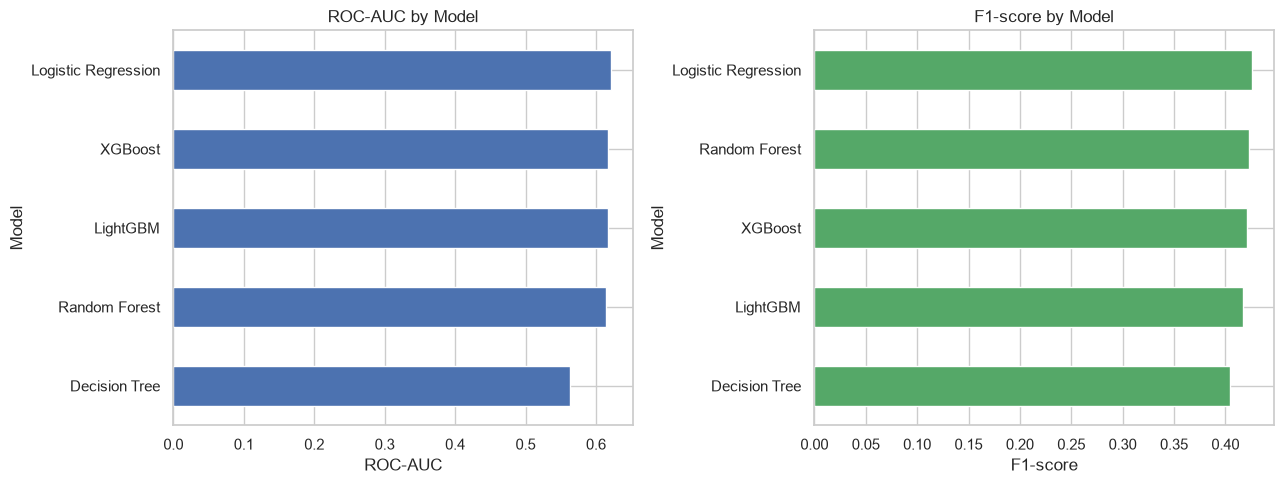

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

comparison_table["ROC-AUC"].sort_values().plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("ROC-AUC by Model")
axes[0].set_xlabel("ROC-AUC")

comparison_table["F1-score"].sort_values().plot(kind="barh", ax=axes[1], color="#55A868")
axes[1].set_title("F1-score by Model")
axes[1].set_xlabel("F1-score")

plt.tight_layout()
plt.show()

## 8. Select and justify the final model


In [8]:
best_model_name = comparison_table["ROC-AUC"].idxmax()
best_model = fitted_models[best_model_name]

print(f"Best performing model: {best_model_name}")
comparison_table.loc[[best_model_name]]

Best performing model: Logistic Regression


,Accuracy,Precision,Recall (Sensitivity),Specificity,F1-score,ROC-AUC,PR-AUC,Cohen's Kappa
Model,,,,,,,,
Logistic Regression,0.5789,0.333,0.5911,0.5745,0.426,0.6215,0.3624,0.1327


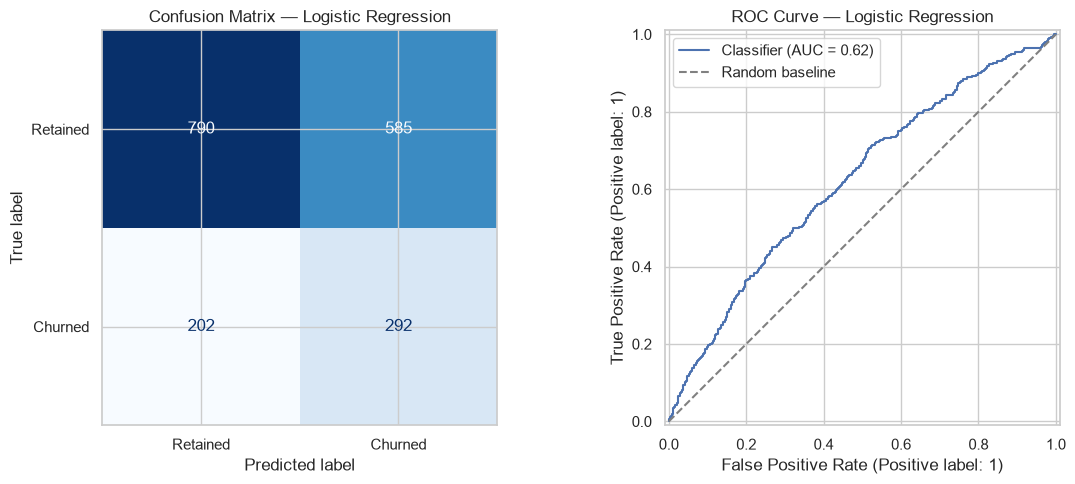

In [10]:
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=["Retained", "Churned"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title(f"Confusion Matrix — {best_model_name}")

RocCurveDisplay.from_predictions(y_test, y_proba_best, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
axes[1].set_title(f"ROC Curve — {best_model_name}")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Save the final model for deployment (Tasks 5 and 6)

In [11]:
import os
os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, f"../models/best_model.pkl")
joblib.dump(best_model_name, "../models/best_model_name.pkl")

# Also save the test set split, for consistent use in Task 5 (XAI)
X_test.to_csv("../data/X_test.csv", index=False)
y_test.to_csv("../data/y_test.csv", index=False)
X_train.to_csv("../data/X_train.csv", index=False)

print(f"Saved best model ({best_model_name}) to models/best_model.pkl")

comparison_table.to_csv("../data/model_comparison_table.csv")
print("Saved comparison table to data/model_comparison_table.csv")

Saved best model (Logistic Regression) to models/best_model.pkl
Saved comparison table to data/model_comparison_table.csv
